# Trajectory viewer/tester


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../src'))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from core import Scene
from processors import TrajVectorizer

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'DejaVu Serif'],
    'text.usetex': True,
    'mathtext.fontset': 'cm',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{siunitx}',
    'savefig.dpi': 300,
})


## Load scene


In [16]:
scene_dir = Path('test_scenes')
scene_files = sorted(scene_dir.glob('*.joblib'), key=lambda p: p.stat().st_mtime)

for i, path in enumerate(scene_files):
    print(f'{i}: {path.name}')

0: scene_crop_b=8_bt=0.5_pe=1.joblib
1: scene_crop_b=8_bt=0.5_pe=1_depth-aligned.joblib
2: scene_crop_b=2_bt=0.2_pe=1_pose-transl.joblib
3: scene_crop_b=2_bt=0.2_pe=1_pose-transl-rot_ball.joblib
4: scene_crop_b=8_bt=0.5_pe=1_pose-transl_box.joblib
5: scene_crop_b=8_bt=0.5_pe=1_pose-transl-rot_box.joblib


In [17]:
scene_id = 4
scene_path = scene_files[scene_id]

scene = Scene.load(str(scene_path))
scene_path.name, scene

('scene_crop_b=8_bt=0.5_pe=1_pose-transl_box.joblib', <Scene with 31 objects>)

## Objects


In [18]:
for obj in scene:
    print(
        f'#{obj.obj_id:<3} '
        f'snaps={obj.num_snapshots:<3} '
        f'poses={obj.trajectory.num_valid:<4}/{obj.num_poses:<4} '
        f'last={obj.last_seen}'
    )

#1   snaps=2   poses=92  /104  last=<BBox 87x12 @ (949, 218), (1036, 230)>
#2   snaps=3   poses=213 /214  last=<BBox 240x207 @ (0, 74), (240, 281)>
#5   snaps=5   poses=159 /166  last=<BBox 195x45 @ (563, 120), (758, 165)>
#9   snaps=1   poses=1   /20   last=<BBox 662x698 @ (366, 381), (1028, 1079)>
#12  snaps=6   poses=152 /152  last=<BBox 169x29 @ (290, 128), (459, 157)>
#25  snaps=7   poses=93  /103  last=<BBox 847x743 @ (79, 337), (926, 1080)>
#26  snaps=3   poses=16  /33   last=<BBox 103x13 @ (930, 218), (1033, 231)>
#44  snaps=1   poses=0   /19   last=<BBox 129x111 @ (716, 576), (845, 687)>
#47  snaps=2   poses=47  /63   last=<BBox 144x13 @ (862, 218), (1006, 231)>
#65  snaps=4   poses=129 /136  last=<BBox 854x753 @ (78, 324), (932, 1077)>
#394 snaps=1   poses=0   /10   last=<BBox 149x13 @ (802, 219), (951, 232)>
#458 snaps=2   poses=17  /23   last=<BBox 54x29 @ (139, 185), (193, 214)>
#461 snaps=2   poses=95  /100  last=<BBox 763x755 @ (0, 4), (763, 759)>
#467 snaps=0   poses=0 

In [19]:
obj_id = max(scene.objects, key=lambda oid: scene[oid].trajectory.num_valid)
# obj_id = 2

obj = scene[obj_id]
traj = obj.trajectory

obj, traj.num_valid

(<RigidObject #2 with 3 snapshots>, 213)

## Snapshots


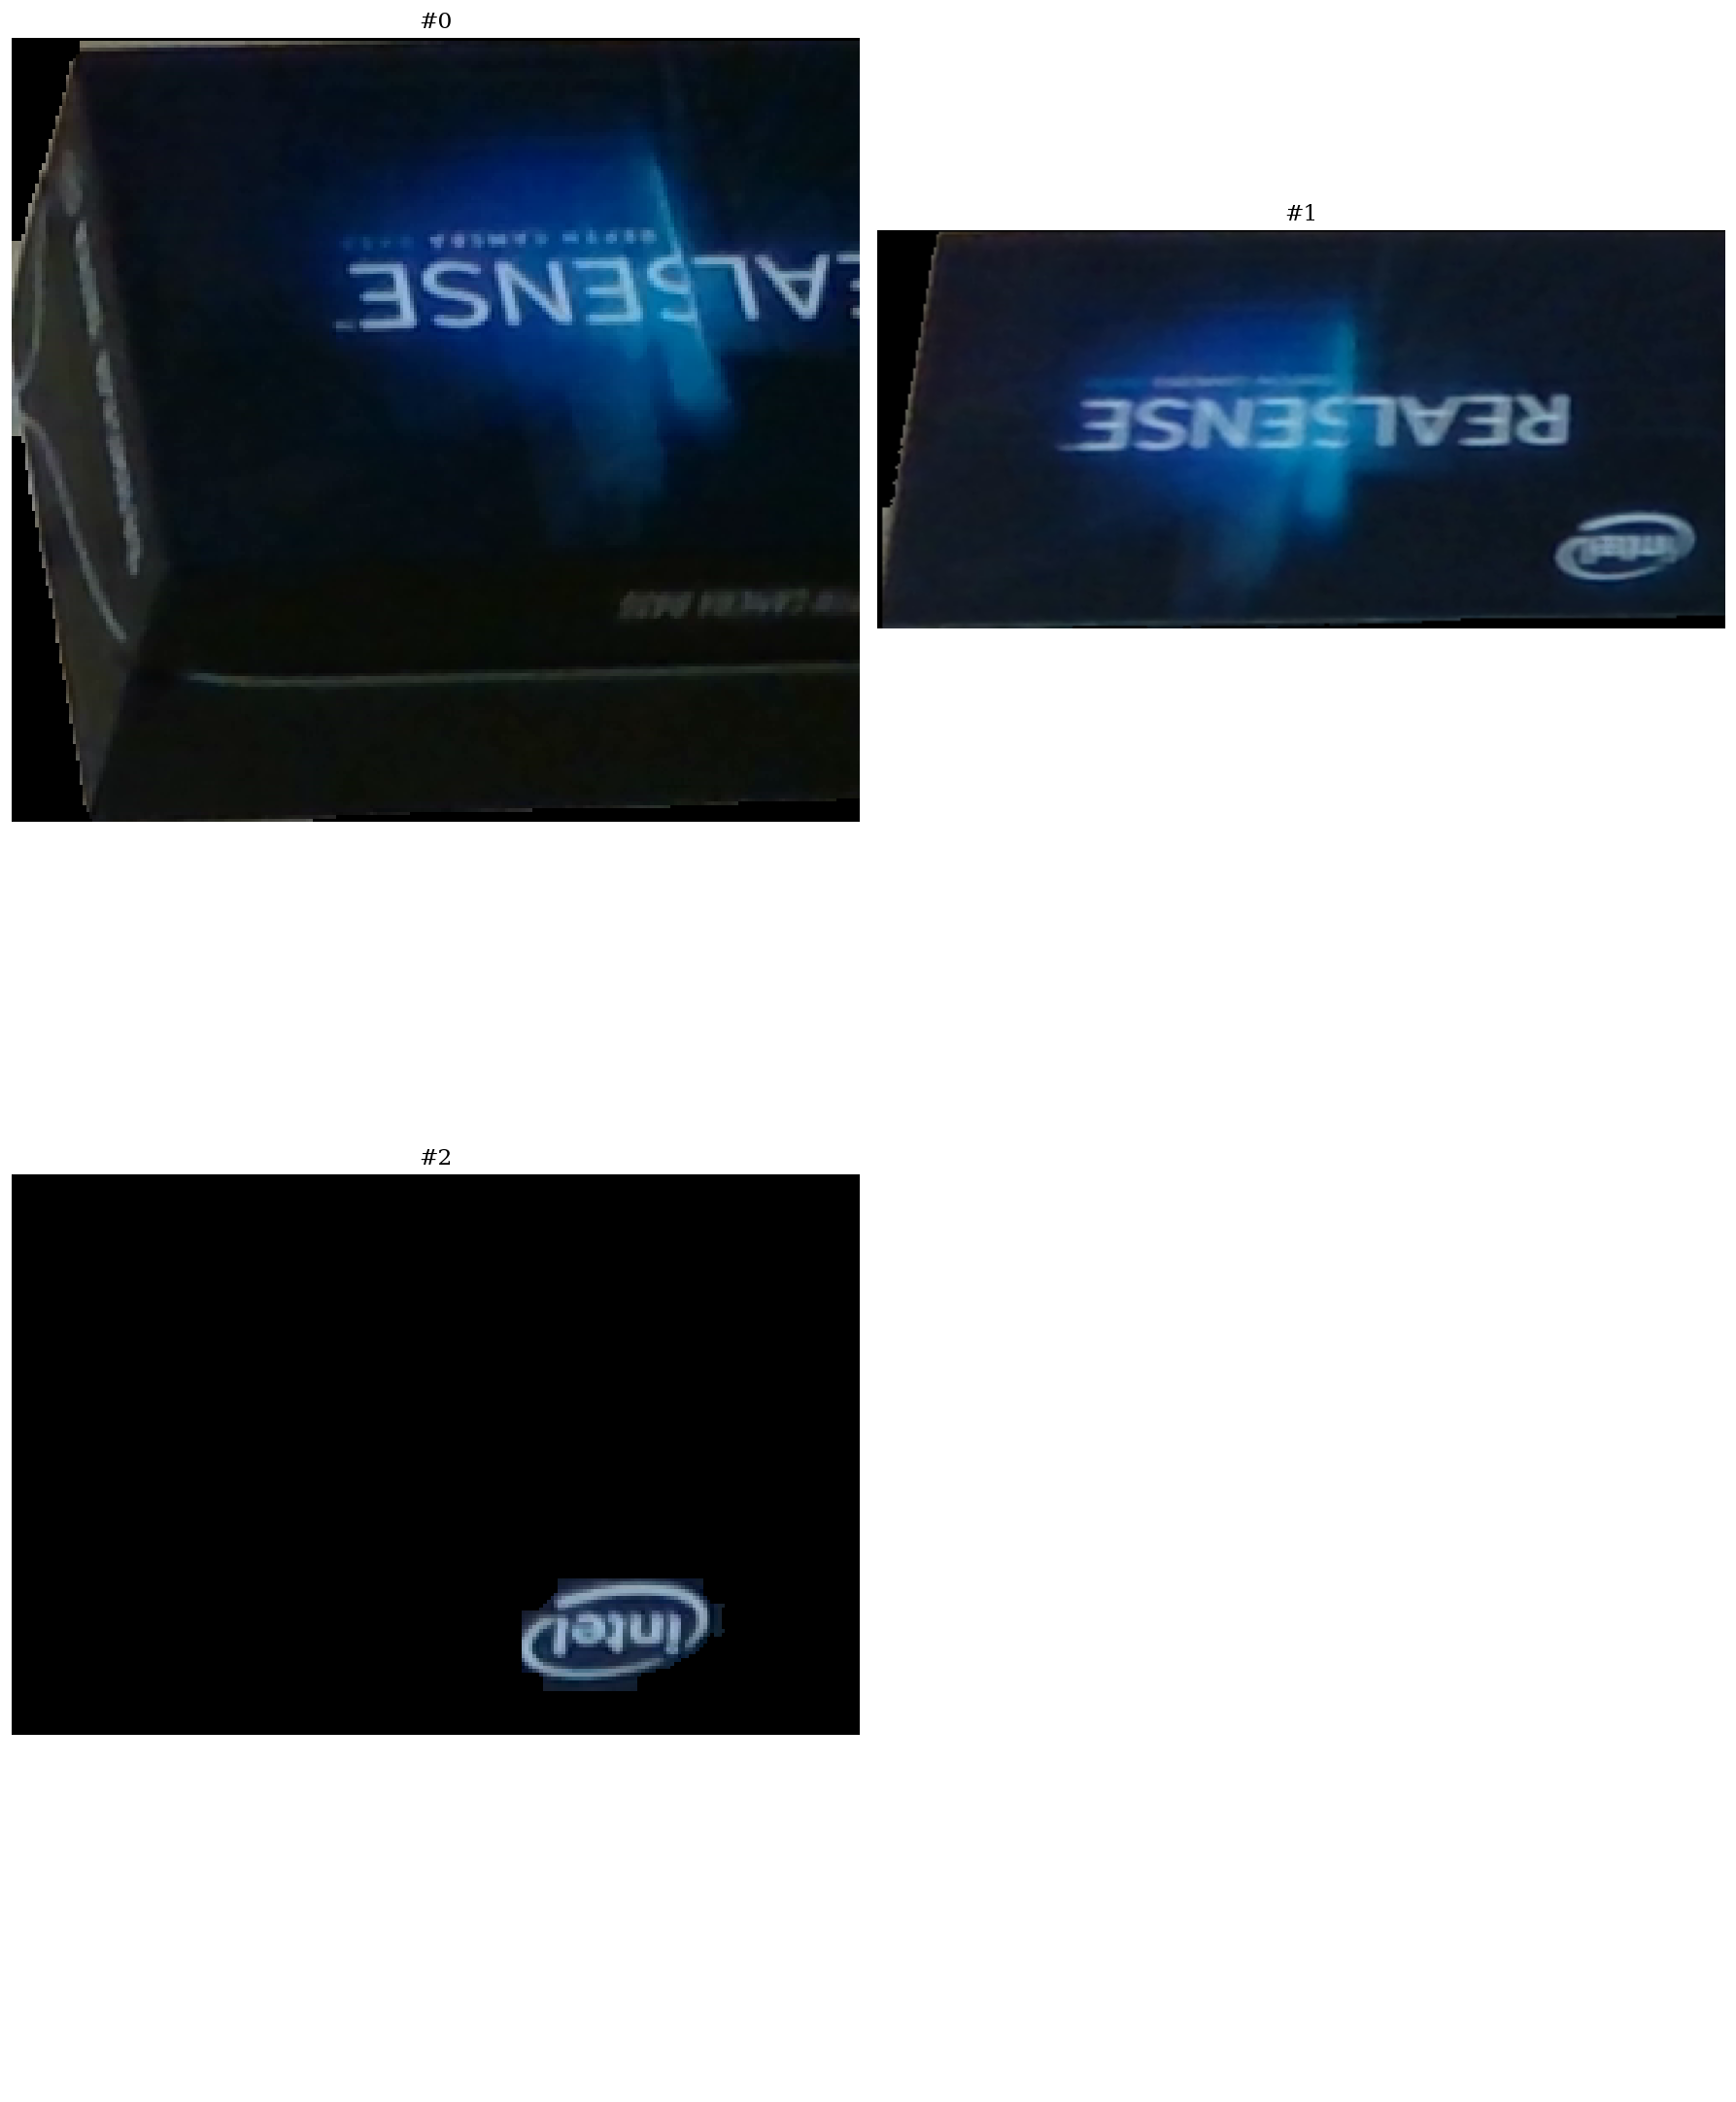

In [20]:
obj.show_snapshots(n=min(12, obj.num_snapshots))

In [21]:
valid = traj.valid

t = np.array([pose.timestamp for pose in valid])
t = t - t[0]

pos = np.array([pose.pos for pose in valid], dtype=np.float32)
rot = np.array([pose.rot for pose in valid], dtype=np.float32)

pos.shape, rot.shape

((213, 3), (213, 3))

## Trajectory


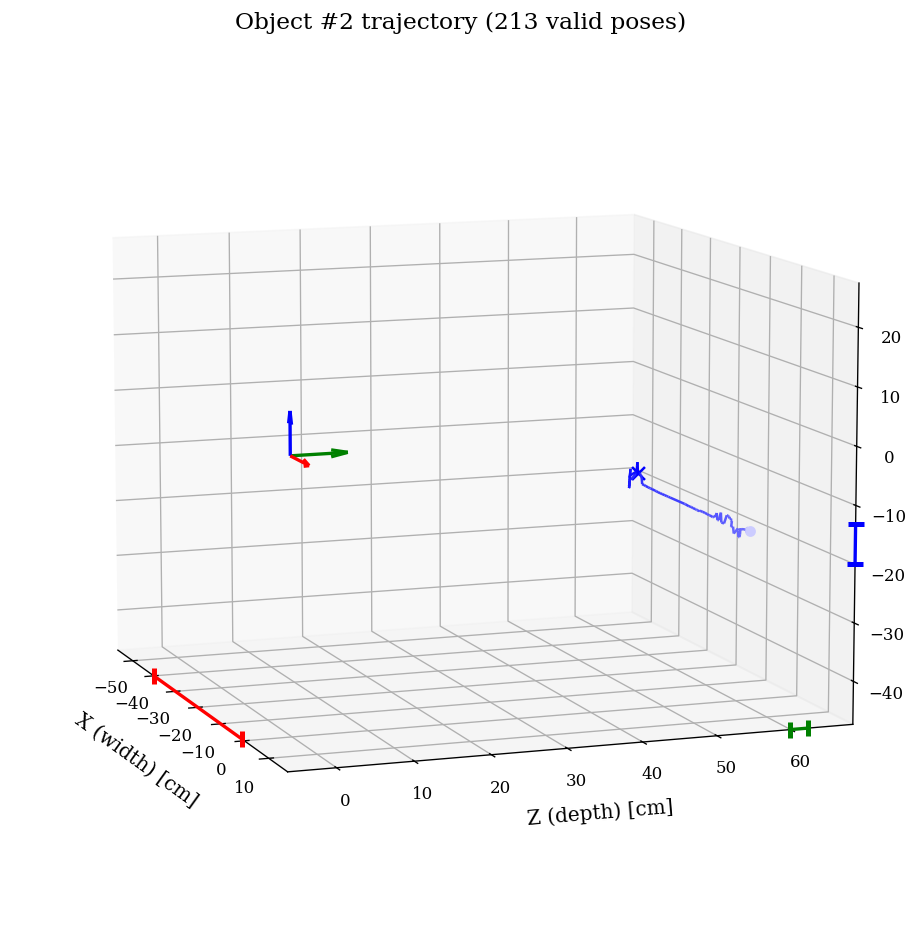

In [27]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

traj.plot(ax=ax, n_orient=0, show=False)
ax.view_init(elev=10, azim=-20)
ax.set_title(f'Object #{obj_id} trajectory ({traj.num_valid} valid poses)')

fig.tight_layout()
plt.show()

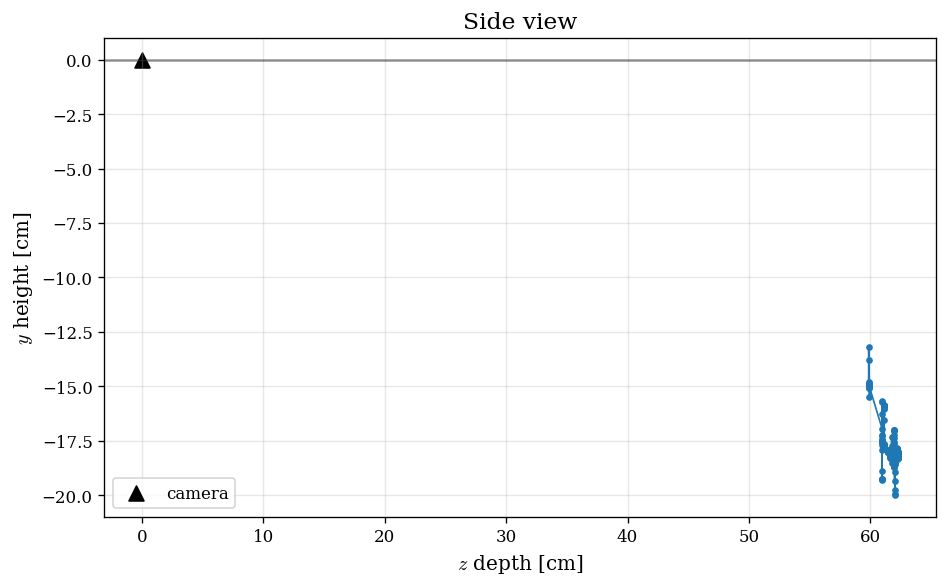

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(pos[:, 2] * 100, pos[:, 1] * 100, marker='.', linewidth=1)
ax.scatter([0], [0], marker='^', color='black', s=80, label='camera')
ax.axhline(0, color='black', alpha=0.4)

ax.set_xlabel(r'$z$ depth [cm]')
ax.set_ylabel(r'$y$ height [cm]')
ax.set_title('Side view')
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

## Signals


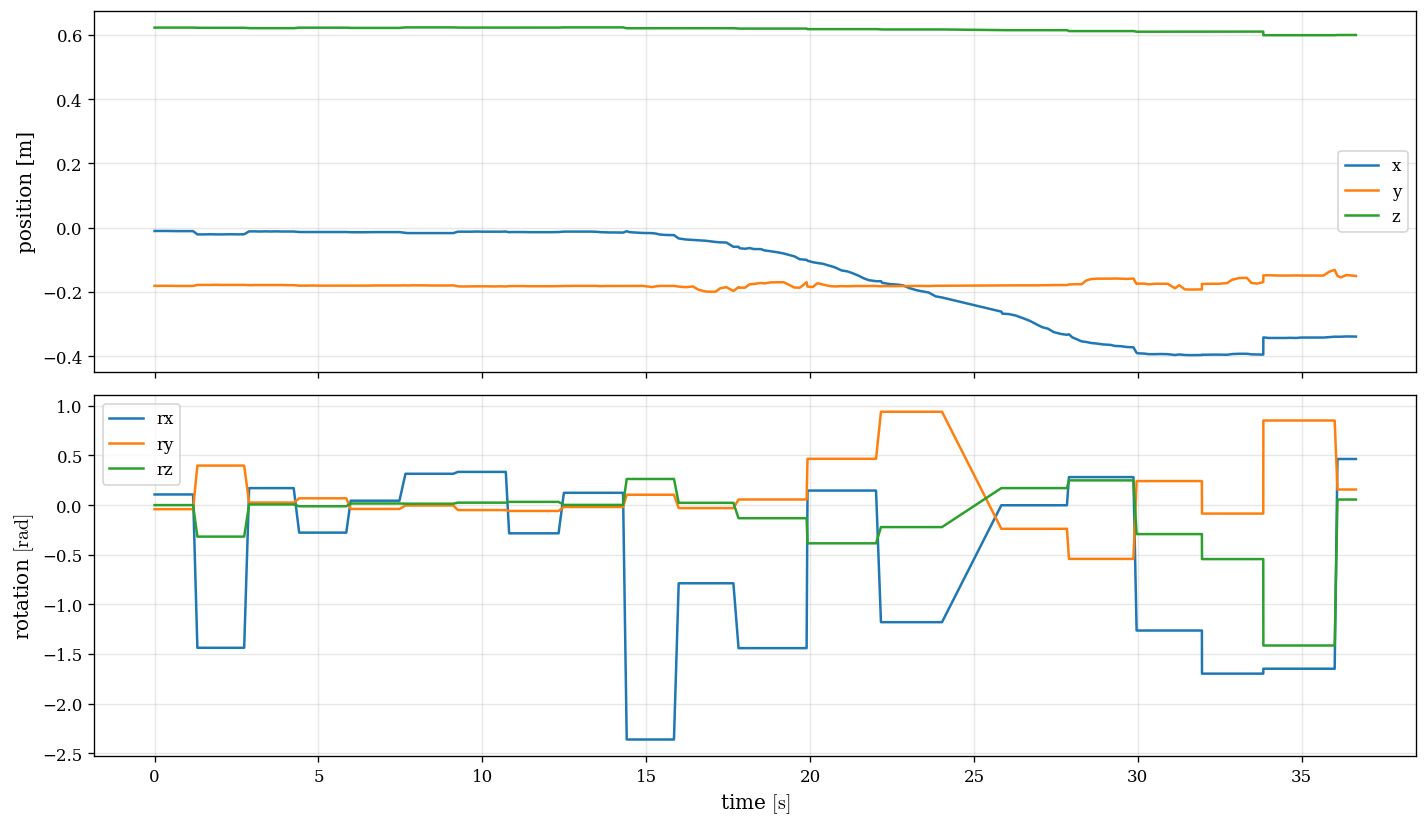

In [29]:
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 7), sharex=True)

for i, label in enumerate(('x', 'y', 'z')):
    ax1.plot(t, pos[:, i], label=label)

for i, label in enumerate(('rx', 'ry', 'rz')):
    ax2.plot(t, np.unwrap(rot[:, i]), label=label)

ax1.set_ylabel('position [m]')
ax2.set_ylabel(r'rotation $[\mathrm{rad}]$')
ax2.set_xlabel(r'time $[\mathrm{s}]$')

ax1.grid(alpha=0.3)
ax2.grid(alpha=0.3)
ax1.legend()
ax2.legend()

fig.tight_layout()
plt.show()

In [30]:
vectorizer = TrajVectorizer(target_len=60, num_pcoeffs=15, num_rcoeffs=15)
traj_vec = vectorizer(traj)

traj_vec.shape, np.isfinite(traj_vec).all()

((90,), np.True_)

## DCT vector


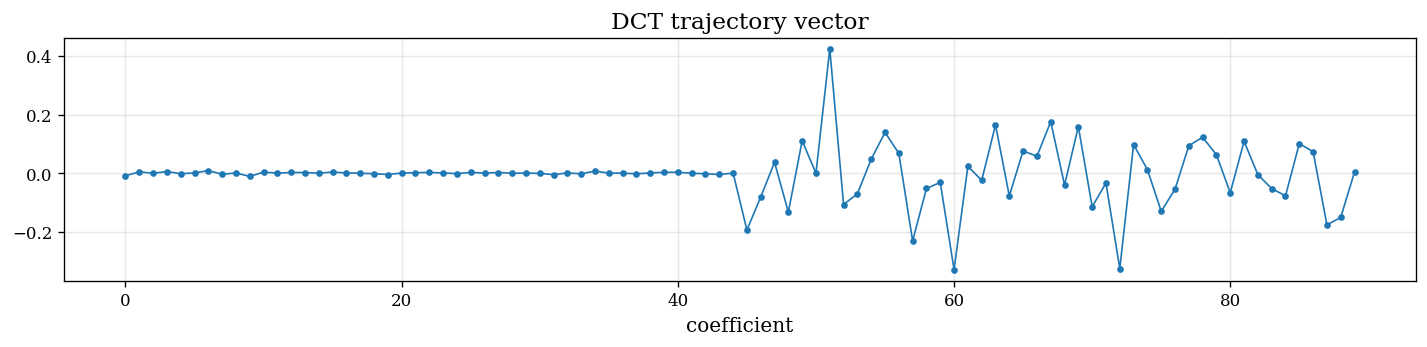

In [31]:
fig, ax = plt.subplots(figsize=(12, 3))

ax.plot(traj_vec, marker='.', linewidth=1)
ax.set_title('DCT trajectory vector')
ax.set_xlabel('coefficient')
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Export


In [32]:
export = True

if export:
    out_dir = Path('trajectory_exports')
    out_dir.mkdir(exist_ok=True)

    np.savez_compressed(
        out_dir / f'{scene_path.stem}_obj-{obj_id}.npz',
        t=t,
        pos=pos,
        rot=rot,
        traj_vec=traj_vec
    )